# Figure 2

![Full Figure](../figures/fig02_FULL.png)

## Code For Figure 2A–C: FixGrower Animals Grow Faster to Fixation Target

**Goal:** Show that FixGrower-trained animals reach the 2-second fixation target significantly faster than Legacy-trained animals, and grow more session-to-session.

| Panel | Description | Data source |
|-------|-------------|-------------|
| A(i) | Example FixGrower trajectory (R043): fixation requirement + avg valid center-poke | `trials_df` |
| A(ii) | All animals: max fixation duration per session over days in curriculum | `trials_df` |
| B | Days to reach 2-second target by curriculum | `trials_df` |
| C | Session-to-session fixation delta by curriculum | `trials_df` |

**Outputs:** `figures/fig02ai_fixgrower_example.png`, `fig02aii_all_animals_fixation_growth.png`, `fig02b_days_to_target.png`, `fig02c_fixation_delta_over_days.png`, `fig02c_fixation_delta_summary.png`

In [1]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import seaborn as sns
from statsmodels.stats.power import TTestIndPower

from fixation_grower import config
from fixation_grower.io import load_trials_df
from fixation_grower.plotting import box_strip_legacy_vs_fixgrower, save_figure
from fixation_grower.stats import (
    compare_fixation_growth_by_day,
    compare_legacy_fixgrower,
    compare_legacy_fixgrower_mixedlm,
)
from fixation_grower.transforms import (
    compute_days_relative_to_stage,
    make_fixation_growth_df,
)

sns.set_context(
    "notebook",
    rc={
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "axes.titleweight": "bold",
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "lines.linewidth": 2,
        "lines.markersize": 7,
    },
)

In [2]:
# FixGrower example (matches manuscript)
EXAMPLE_ANIMAL = config.FIXGROWER_DEMO_ANIMAL
MAX_DAYS_PANEL_C_LINE = 7  # Panel C exploratory line: days tested + Bonferroni factor
TARGET_S = 2.0
REL_STAGE = 5

tdf = load_trials_df()
tdf = compute_days_relative_to_stage(tdf, stage=REL_STAGE)
tdf["days_relative_to_stage_5_adj"] = tdf["days_relative_to_stage_5"] + 1

## Panel A(i) — Example FixGrower trajectory (trial-level aggregation)

**Fixation requirement** (`fixation_dur`, max within each curriculum day): what the animal must satisfy on valid trials.

**Average valid center-poke** (`cpoke_dur`, mean within each day): performance used to schedule the next session’s requirement in FixGrower.

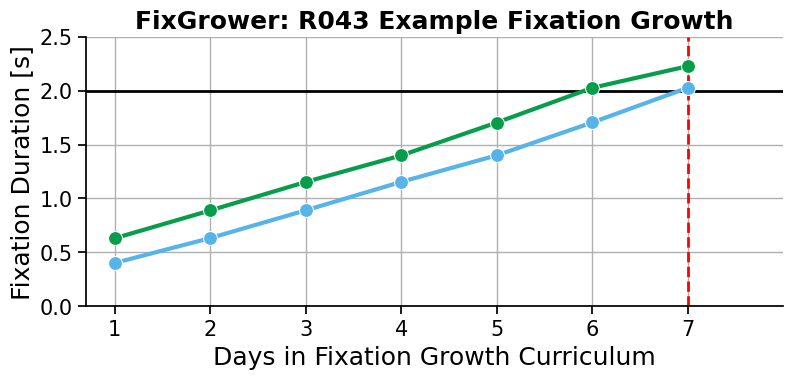

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
plot_ai = tdf.query(
    "stage in @config.GROWING_STAGES and animal_id == @EXAMPLE_ANIMAL"
)

sns.lineplot(
    data=plot_ai,
    x="days_relative_to_stage_5_adj",
    y="fixation_dur",
    estimator="max",
    ax=ax,
    color=config.FIXGROWER_COLOR,
    marker="o",
    markersize=10,
    linewidth=3,
    zorder=10,
)

sns.lineplot(
    data=plot_ai,
    x="days_relative_to_stage_5_adj",
    y="cpoke_dur",
    estimator="mean",
    errorbar=None,
    ax=ax,
    color=config.VALID_COLOR,
    marker="o",
    markersize=10,
    linewidth=3,
    zorder=10,
)

xmax_ai = 8
ax.set_xticks(range(1, xmax_ai, 1))
ax.grid()
ax.axhline(TARGET_S, color="k", lw=2)
ax.set(
    ylabel="Fixation Duration [s]",
    xlabel="Days in Fixation Growth Curriculum",
    ylim=(0, 2.5),
    xlim=(None, xmax_ai),
)
ax.set_title(
    f"FixGrower: {EXAMPLE_ANIMAL} Example Fixation Growth",
    fontweight="bold",
)

daily_max = (
    plot_ai.groupby("days_relative_to_stage_5_adj",
                    as_index=False)["fixation_dur"]
    .max()
)
_hit_days = daily_max.loc[
    daily_max["fixation_dur"] >= TARGET_S, "days_relative_to_stage_5_adj"
]
if not _hit_days.empty:
    ax.axvline(float(_hit_days.iloc[0]), color="r", lw=2, ls="--")

sns.despine()
save_figure(fig, "fig02ai_fixgrower_example")

## Panel A(ii) — All animals: maximum fixation duration per curriculum day

One trajectory per animal; color indicates curriculum (**Legacy** vs **FixGrower**).

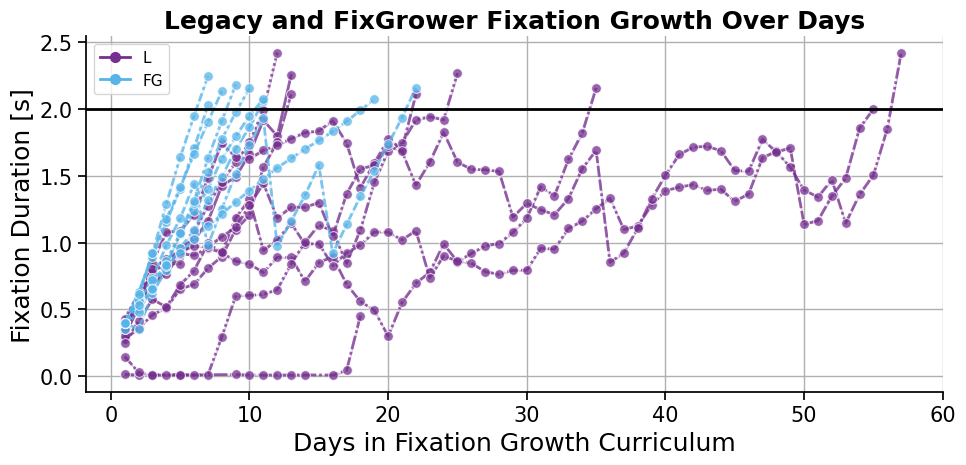

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_aii = tdf.query("stage in @config.GROWING_STAGES")

sns.lineplot(
    data=plot_aii,
    x="days_relative_to_stage_5_adj",
    y="fixation_dur",
    estimator="max",
    ax=ax,
    hue="fix_experiment",
    hue_order=config.HUE_ORDER_EXP,
    palette=config.EXP_PALETTE,
    style="animal_id",
    marker="o",
    alpha=0.75,
    legend=False,
)

ax.legend(
    handles=[
        mlines.Line2D(
            [],
            [],
            color=config.LEGACY_COLOR,
            marker="o",
            linestyle="-",
            label="L",
        ),
        mlines.Line2D(
            [],
            [],
            color=config.FIXGROWER_COLOR,
            marker="o",
            linestyle="-",
            label="FG",
        ),
    ],
    loc="upper left",
)

ax.grid()
ax.axhline(TARGET_S, color="k", lw=2)
ax.set(
    ylabel="Fixation Duration [s]",
    xlabel="Days in Fixation Growth Curriculum",
    xlim=(None, 60),
)
ax.set_title(
    "Legacy and FixGrower Fixation Growth Over Days",
    fontweight="bold",
)
sns.despine()
plt.tight_layout()
save_figure(fig, "fig02aii_all_animals_fixation_growth")

## Panel B — Days to reach the fixation target

Per animal: first dense-rank day (relative to stage 5) at which `has_reached_target_fixation` is true.

In [5]:
days_to_target = (
    tdf.query("has_reached_target_fixation == True")
    .groupby(["animal_id", "fix_experiment"], observed=True)["days_relative_to_stage_5"]
    .min()
    .reset_index()
    .rename(columns={"days_relative_to_stage_5": "days_to_target"})
)

days_to_target.groupby("fix_experiment")["days_to_target"].agg(
    ["median", "mean", "std", "size"]
)

,median,mean,std,size
fix_experiment,,,,
FixGrower,10.0,11.444444,5.456902,9
Legacy,23.5,29.000000,18.369229,8


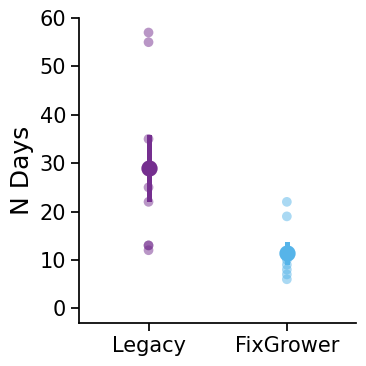

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.despine()

sns.pointplot(
    days_to_target,
    x="fix_experiment",
    order=config.HUE_ORDER_EXP,
    y="days_to_target",
    ax=ax,
    linestyle="none",
    errorbar="se",
    hue="fix_experiment",
    hue_order=config.HUE_ORDER_EXP,
    palette=config.EXP_PALETTE,
)

sns.stripplot(
    days_to_target,
    x="fix_experiment",
    order=config.HUE_ORDER_EXP,
    y="days_to_target",
    ax=ax,
    hue="fix_experiment",
    hue_order=config.HUE_ORDER_EXP,
    palette=config.EXP_PALETTE,
    alpha=0.5,
    jitter=False,
    s=7,
)

ax.set_ylim(-3, 60)
ax.set_title("", fontweight="bold")
ax.set(xlabel="", ylabel="N Days")
plt.tight_layout()
save_figure(fig, "fig02b_days_to_target")

In [7]:
print(compare_legacy_fixgrower(days_to_target, "days_to_target").to_string())

group_legacy = days_to_target.loc[
    days_to_target["fix_experiment"] == "Legacy", "days_to_target"
].to_numpy()
group_fixgrower = days_to_target.loc[
    days_to_target["fix_experiment"] == "FixGrower", "days_to_target"
].to_numpy()

mean_legacy = float(np.mean(group_legacy))
mean_fixgrower = float(np.mean(group_fixgrower))
std_legacy = float(np.std(group_legacy, ddof=1))
std_fixgrower = float(np.std(group_fixgrower, ddof=1))

n_legacy = len(group_legacy)
n_fixgrower = len(group_fixgrower)

print(
    f"Legacy mean: {mean_legacy:.3f}, std: {std_legacy:.3f}, n: {n_legacy}"
)
print(
    f"FixGrower mean: {mean_fixgrower:.3f}, std: {std_fixgrower:.3f}, n: {n_fixgrower}"
)

pooled_std = np.sqrt(
    ((n_legacy - 1) * std_legacy**2 + (n_fixgrower - 1) * std_fixgrower**2)
    / (n_legacy + n_fixgrower - 2)
)
effect_size = (mean_legacy - mean_fixgrower) / pooled_std

print(f"Pooled Std Dev: {pooled_std:.3f}")
print(f"Effect size (Cohen's d): {effect_size:.3f}")

analysis = TTestIndPower()
ratio = n_fixgrower / n_legacy
power = analysis.power(
    effect_size=effect_size,
    nobs1=n_legacy,
    alpha=0.05,
    ratio=ratio,
    alternative="two-sided",
)
print(f"Observed power: {power:.4f}")

   normality_Legacy  normality_FixGrower  n_Legacy  n_FixGrower    test_type  test_statistic  p_val_raw
0              True                False         8            9  mannwhitney            65.5   0.005179
Legacy mean: 29.000, std: 18.369, n: 8
FixGrower mean: 11.444, std: 5.457, n: 9
Pooled Std Dev: 13.166
Effect size (Cohen's d): 1.333
Observed power: 0.7275


## Panel C — Session-to-session fixation delta

**Summary boxplot:** all session-pair deltas in growing stages (`make_fixation_growth_df`).

**Exploratory line panel:** mean ± SE per curriculum day with per-day comparisons (Mann–Whitney; stars use raw *p*-values like the original notebook).

In [8]:
fixation_growth_df = make_fixation_growth_df(
    tdf.query("stage in @config.GROWING_STAGES").copy()
)

fixation_growth_df.groupby("fix_experiment")["fixation_growth"].agg(
    ["median", "mean", "std", "size"]
)

,median,mean,std,size
fix_experiment,,,,
FixGrower,0.199544,0.163639,0.176251,104
Legacy,0.066538,0.066602,0.168563,245


   normality_Legacy  normality_FixGrower  n_Legacy  n_FixGrower    test_type  test_statistic     p_val_raw
0             False                False       236           95  mannwhitney          5654.0  1.740188e-12
                  test_type  test_statistic  p_val_raw  residuals_normal
0  mixedlm_random_intercept        3.088459   0.002012             False


/Users/bredaj/Library/CloudStorage/OneDrive-Cedars-SinaiHealthSystem/github/Breda-Charlton-FixationGrower/src/fixation_grower/plotting.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=None, frameon=False)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


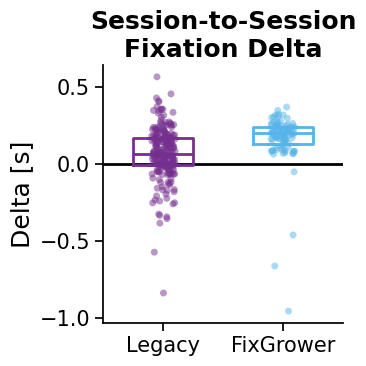

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))

box_strip_legacy_vs_fixgrower(
    fixation_growth_df,
    x="fix_experiment",
    order=config.HUE_ORDER_EXP,
    y="fixation_growth",
    ax=ax,
    xlabel="",
    ylabel="Fixation Growth [s]",
    dodge=False,
    s=5,
    alpha=0.5,
)

ax.axhline(0, color="black", zorder=0)
ax.set(ylabel="Delta [s]", xlabel="")
ax.set_title("Session-to-Session\nFixation Delta", fontweight="bold")
plt.tight_layout()
save_figure(fig, "fig02c_fixation_delta_summary")

fg_clean = fixation_growth_df.dropna(subset=["fixation_growth"])
print(compare_legacy_fixgrower(fg_clean, "fixation_growth").to_string())
print(compare_legacy_fixgrower_mixedlm(
    fg_clean, "fixation_growth").to_string())